# Forecasting of Smart City Traffic Patterns

### Install Required Libraries

In [1]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install xgboost
!pip install Prophet

### Import Libraries

In [2]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet

### Load The Dataset

In [3]:
# Load the training dataset
df_train = pd.read_csv("train_aWnotuB.csv")

# Display first 5 rows of the dataset
df_train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
# Load the testing dataset
df_test = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")

# Display first 5 rows of the dataset
df_test.head()

,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041


### Understand the Data

In [5]:
# Display basic information about the training dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [6]:
# Display basic information about the testing dataset
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  11808 non-null  object
 1   Junction  11808 non-null  int64 
 2   ID        11808 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 276.9+ KB


In [7]:
# Display statistical summary
df_train.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [8]:
# Display statistical summary
df_test.describe()

,Junction,ID
count,11808.000000,1.180800e+04
mean,2.500000,2.017087e+10
std,1.118081,1.124665e+05
min,1.000000,2.017070e+10
25%,1.750000,2.017073e+10
50%,2.500000,2.017083e+10
75%,3.250000,2.017100e+10
max,4.000000,2.017103e+10


In [9]:
# Check training column names
df_train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [10]:
# Check testing column names
df_test.columns

Index(['DateTime', 'Junction', 'ID'], dtype='object')

### Convert DateTime and Extract Features

In [11]:
# Convert 'DateTime' to proper datetime objects
df_train['DateTime'] = pd.to_datetime(df_train['DateTime'])
df_test['DateTime'] = pd.to_datetime(df_test['DateTime'])

In [12]:
# Extract time-based features for training data
df_train['Year'] = df_train['DateTime'].dt.year
df_train['Month'] = df_train['DateTime'].dt.month
df_train['Day'] = df_train['DateTime'].dt.day
df_train['Hour'] = df_train['DateTime'].dt.hour
df_train['DayOfWeek'] = df_train['DateTime'].dt.dayofweek

In [13]:
# Extract time-based features for testing data
df_test['Year'] = df_test['DateTime'].dt.year
df_test['Month'] = df_test['DateTime'].dt.month
df_test['Day'] = df_test['DateTime'].dt.day
df_test['Hour'] = df_test['DateTime'].dt.hour
df_test['DayOfWeek'] = df_test['DateTime'].dt.dayofweek

#### Drop Unnecessary Columns

In [14]:
# Save test IDs for final prediction submission
test_ids = df_test['ID']

# Drop 'ID' and 'DateTime' columns from both datasets as they are no longer needed
df_train = df_train.drop(['ID', 'DateTime'], axis=1)
df_test = df_test.drop(['ID', 'DateTime'], axis=1)

# Display updated training data to verify new features
display(df_train.head())

,Junction,Vehicles,Year,Month,Day,Hour,DayOfWeek
0,1,15,2015,11,1,0,6
1,1,13,2015,11,1,1,6
2,1,10,2015,11,1,2,6
3,1,7,2015,11,1,3,6
4,1,9,2015,11,1,4,6


### Data Visualization (Exploratory Data Analysis)

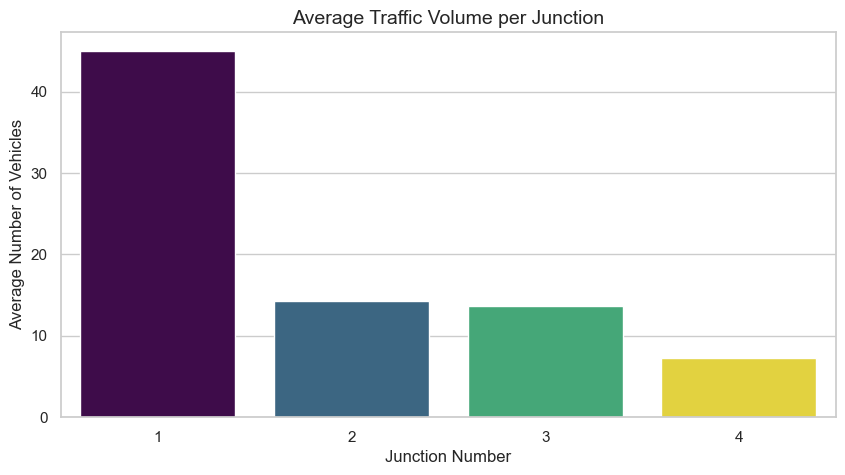

In [15]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Average Traffic by Junction
plt.figure(figsize=(10, 5))
sns.barplot(x='Junction', y='Vehicles', data=df_train, errorbar=None, palette='viridis', hue='Junction', legend=False)
plt.title('Average Traffic Volume per Junction', fontsize=14)
plt.xlabel('Junction Number', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.show()

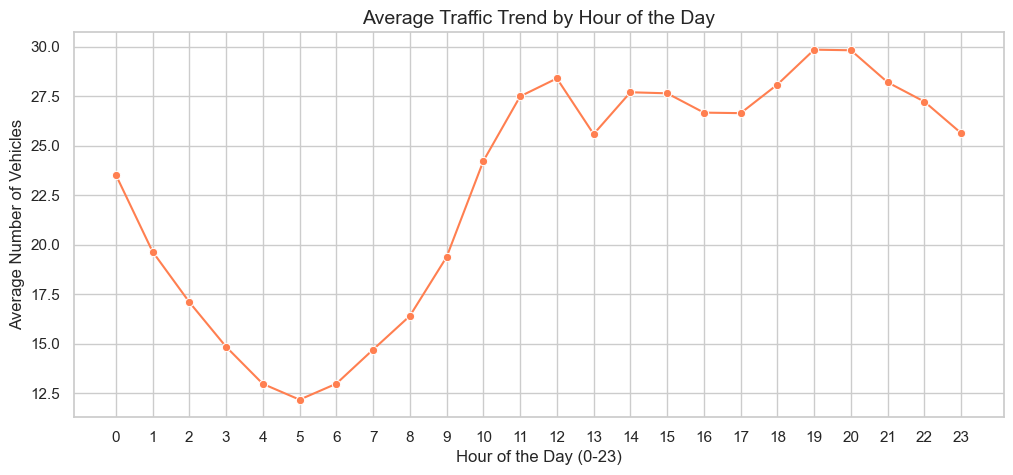

In [16]:
# Traffic Trend by Hour of the Day
# This shows the peak traffic hours across the entire city
plt.figure(figsize=(12, 5))
sns.lineplot(x='Hour', y='Vehicles', data=df_train, errorbar=None, color='coral', marker='o')
plt.title('Average Traffic Trend by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.xticks(range(0, 24))
plt.show()

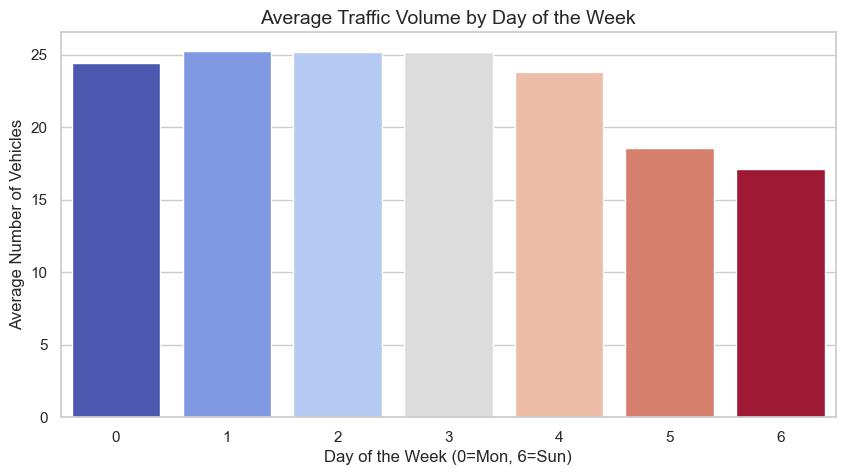

In [17]:
# Traffic Trend by Day of the Week
# 0 = Monday, 6 = Sunday. This shows if weekends have less traffic.
plt.figure(figsize=(10, 5))
sns.barplot(x='DayOfWeek', y='Vehicles', data=df_train, errorbar=None, palette='coolwarm', hue='DayOfWeek', legend=False)
plt.title('Average Traffic Volume by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week (0=Mon, 6=Sun)', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.show()

### Split Data into Training and Validation

In [18]:
from sklearn.model_selection import train_test_split

# Define Features (X)
X = df_train.drop('Vehicles', axis=1)

# Define Target (y)
y = df_train['Vehicles']

# Split the data: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the size of the splits
print(f"X_train shape (Training Data): {X_train.shape}")
print(f"X_test shape (Validation Data): {X_test.shape}")

X_train shape (Training Data): (38496, 6)
X_test shape (Validation Data): (9624, 6)


### Train The Machine Learning Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
print("Training the model...")
rf_model.fit(X_train, y_train)

# Confirmation message
print("Model training completed successfully!")

Training the model...
Model training completed successfully!


### Make Predictions and Evaluate Model

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on the validation data
print("Generating predictions on validation data...")
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the evaluation results
print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} (Average error in vehicle count)")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f} (Closer to 1.0 is better)")

Generating predictions on validation data...

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 2.40 (Average error in vehicle count)
Root Mean Squared Error (RMSE): 3.56
R-squared (R2) Score: 0.9690 (Closer to 1.0 is better)


### Visualize Actual vs Predicted (Post-Modeling EDA)

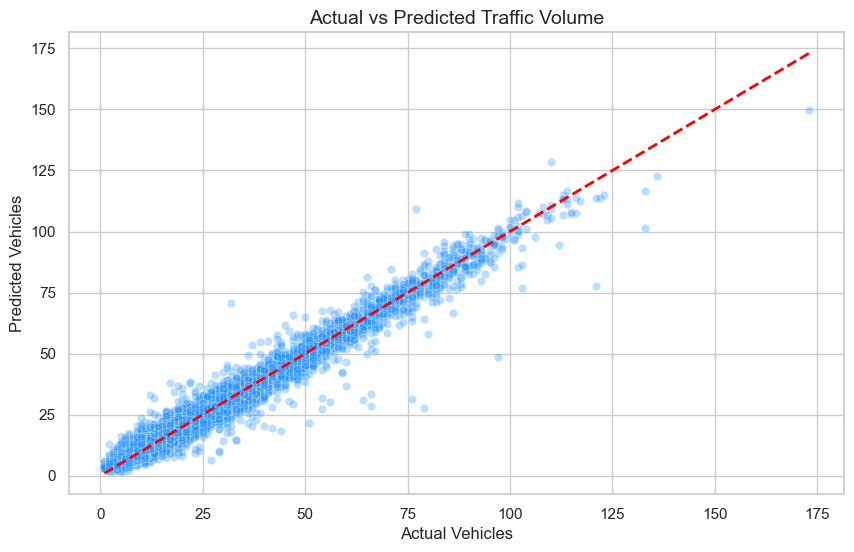

In [21]:
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='dodgerblue')

# Draw a perfect prediction diagonal line (Red dashed line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

# Titles and labels
plt.title('Actual vs Predicted Traffic Volume', fontsize=14)
plt.xlabel('Actual Vehicles', fontsize=12)
plt.ylabel('Predicted Vehicles', fontsize=12)

# Show the plot
plt.show()

### Final Predictions

In [22]:
# Make predictions on the completely unseen testing data
print("Generating final predictions for test_traffic.csv...")
final_predictions = rf_model.predict(df_test)

# Create a DataFrame in the format required for submission
# Round the predictions and convert to integers since vehicle count can't be fractional
submission_df = pd.DataFrame({
    'ID': test_ids,
    'Vehicles': np.round(final_predictions).astype(int)
})

# Save the results to a new CSV file
submission_df.to_csv('traffic_submission.csv', index=False)

# Display success message and preview of the output
print("Final submission file 'traffic_submission.csv' has been created and saved!")
display(submission_df.head())

Generating final predictions for test_traffic.csv...
Final submission file 'traffic_submission.csv' has been created and saved!


,ID,Vehicles
0,20170701001,67
1,20170701011,61
2,20170701021,43
3,20170701031,38
4,20170701041,32


### Save the Model (Deployment Ready)

In [23]:
import joblib

# Save the trained model to a file
joblib.dump(rf_model, 'traffic_forecasting_model.pkl')
print("Model saved as 'traffic_forecasting_model.pkl'")

Model saved as 'traffic_forecasting_model.pkl'


### Feature Importance (Analysis)

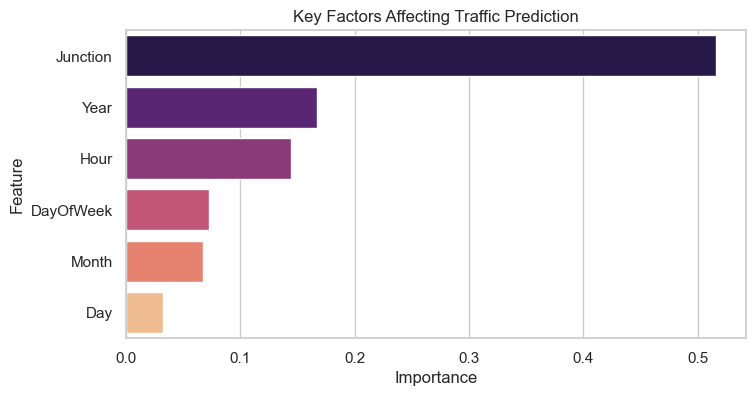

In [24]:
# Check which features are most important for the model
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma', hue='Feature', legend=False)
plt.title('Key Factors Affecting Traffic Prediction')
plt.show()